# NAVYA — Data Exploration

This notebook audits the untouched source data, validates its longitudinal structure, and establishes the previous-three-cycle baseline. It makes no changes to the raw CSV.

## 1. Imports and project paths

This cell imports analysis libraries and resolves the project root whether the notebook is launched from the root or `notebooks/`.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
RAW_PATH = ROOT / "data" / "calibrated_menstrual_cycle_ml_dataset.csv"
sns.set_theme(style="whitegrid", context="notebook")

## 2. Load and inspect the raw dataset

The following cells report shape, schema, endpoints, missingness, duplicates, and descriptive statistics without changing values.

In [3]:
raw = pd.read_csv(RAW_PATH)
print(f"Shape: {raw.shape}")
display(pd.DataFrame({"column": raw.columns, "dtype": raw.dtypes.astype(str).values}))
display(raw.head(3))
display(raw.tail(3))
display(raw.describe(include="all").T)
missing = pd.DataFrame(
    {"missing_count": raw.isna().sum(), "missing_pct": raw.isna().mean().mul(100)}
).sort_values("missing_pct", ascending=False)
display(missing)
print("Duplicate rows:", raw.duplicated().sum())

Shape: (20000, 30)


,column,dtype
0,age,float64
1,height,float64
2,weight,float64
3,bmi,float64
4,age_at_menarche,int64
5,medication_contraceptive,str
6,stress,str
7,sleep,float64
8,exercise,str
9,prev1_cycle_length,int64


,age,height,weight,bmi,age_at_menarche,medication_contraceptive,stress,sleep,exercise,prev1_cycle_length,...,prev1_symptom_mood_swings,prev2_symptom_cramps,prev2_symptom_fatigue,prev2_symptom_mood_swings,prev3_symptom_cramps,prev3_symptom_fatigue,prev3_symptom_mood_swings,next_cycle_length,next_period_length,next_is_irregular
0,24.0,5.0,37.8,16.3,12,No,Moderate,7.4,Never,31,...,False,True,False,True,False,True,True,31,5,False
1,24.0,5.0,37.8,16.3,12,No,Moderate,7.4,Never,31,...,False,True,True,False,True,False,True,31,5,False
2,24.0,5.0,37.7,16.2,12,No,Moderate,7.3,Never,31,...,True,True,True,False,True,True,False,31,5,False


,age,height,weight,bmi,age_at_menarche,medication_contraceptive,stress,sleep,exercise,prev1_cycle_length,...,prev1_symptom_mood_swings,prev2_symptom_cramps,prev2_symptom_fatigue,prev2_symptom_mood_swings,prev3_symptom_cramps,prev3_symptom_fatigue,prev3_symptom_mood_swings,next_cycle_length,next_period_length,next_is_irregular
19997,20.0,5.4,51.1,19.3,15,No,Moderate,5.9,1-2 days/week,28,...,False,True,True,True,True,True,True,27,7,False
19998,20.0,5.4,51.0,19.3,15,No,Moderate,5.9,1-2 days/week,27,...,True,True,False,False,True,True,True,27,6,False
19999,20.0,5.4,51.0,19.3,15,No,Moderate,5.9,1-2 days/week,27,...,True,False,True,True,True,False,False,27,7,False


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,20000.0,NaN,NaN,NaN,25.279,6.421933,16.0,21.0,24.0,27.0,45.0
height,20000.0,NaN,NaN,NaN,5.2375,0.309497,4.4,5.0,5.2,5.4,6.0
weight,20000.0,NaN,NaN,NaN,54.930335,9.875313,35.0,47.6,54.8,61.5,83.7
bmi,20000.0,NaN,NaN,NaN,22.071985,3.020215,15.1,19.9,22.0,24.2,29.7
age_at_menarche,20000.0,NaN,NaN,NaN,12.797,1.353471,9.0,12.0,13.0,14.0,16.0
medication_contraceptive,20000,3,No,16200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stress,20000,5,Moderate,11624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep,20000.0,NaN,NaN,NaN,6.260505,0.841435,3.5,5.8,6.3,6.8,8.9
exercise,20000,4,1-2 days/week,7960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prev1_cycle_length,20000.0,NaN,NaN,NaN,29.13835,3.862623,15.0,27.0,29.0,31.0,50.0


,missing_count,missing_pct
age,0,0.0
height,0,0.0
weight,0,0.0
bmi,0,0.0
age_at_menarche,0,0.0
medication_contraceptive,0,0.0
stress,0,0.0
sleep,0,0.0
exercise,0,0.0
prev1_cycle_length,0,0.0


Duplicate rows: 0


## 3. Categorical values and range checks

This cell exposes category spellings and flags values outside clinically plausible broad checks. Flags are diagnostic, not automatic row removal.

In [4]:
categorical = raw.select_dtypes(include=["object", "bool"]).columns.tolist()
for c in categorical:
    print(f"\n{c}")
    display(raw[c].value_counts(dropna=False))
checks = {
    "age": (8, 100),
    "height": (3, 8),
    "weight": (25, 250),
    "sleep": (1, 24),
    "next_cycle_length": (15, 60),
    "next_period_length": (1, 14),
}
range_report = pd.DataFrame(
    [
        {
            "column": c,
            "outside_broad_range": (
                (pd.to_numeric(raw[c], errors="coerce") < lo)
                | (pd.to_numeric(raw[c], errors="coerce") > hi)
            ).sum(),
        }
        for c, (lo, hi) in checks.items()
    ]
)
display(range_report)


medication_contraceptive


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31168\395265669.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = raw.select_dtypes(include=["object", "bool"]).columns.tolist()


medication_contraceptive
No          16200
Yes          3220
Not Sure      580
Name: count, dtype: int64


stress


stress
Moderate     11624
Low           3046
High          2949
Very High     1855
Very Low       526
Name: count, dtype: int64

...


prev3_symptom_mood_swings


prev3_symptom_mood_swings
True     13026
False     6974
Name: count, dtype: int64


next_is_irregular


next_is_irregular
False    18183
True      1817
Name: count, dtype: int64

,column,outside_broad_range
0,age,0
1,height,0
2,weight,0
3,sleep,0
4,next_cycle_length,0
5,next_period_length,0


## 4. Distributions and correlations

These plots show target, history, stress, exercise, medication, period-length distributions, and numeric correlation. The BMI comparison tests both decimal-feet and feet-and-inches interpretations against the source BMI; the feet-and-inches interpretation is carried into preprocessing.

,raw_bmi,decimal_feet_bmi,feet_inches_bmi,difference_from_feet_inches
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,22.071985,21.484363,22.071821,0.000164
std,3.020215,2.947158,3.020043,0.031170
min,15.100000,14.718784,15.112530,-0.071113
25%,19.900000,19.247373,19.923185,-0.024301
50%,22.000000,21.518855,22.035787,0.000346
75%,24.200000,23.637547,24.212696,0.024746
max,29.700000,29.199358,29.758185,0.074315


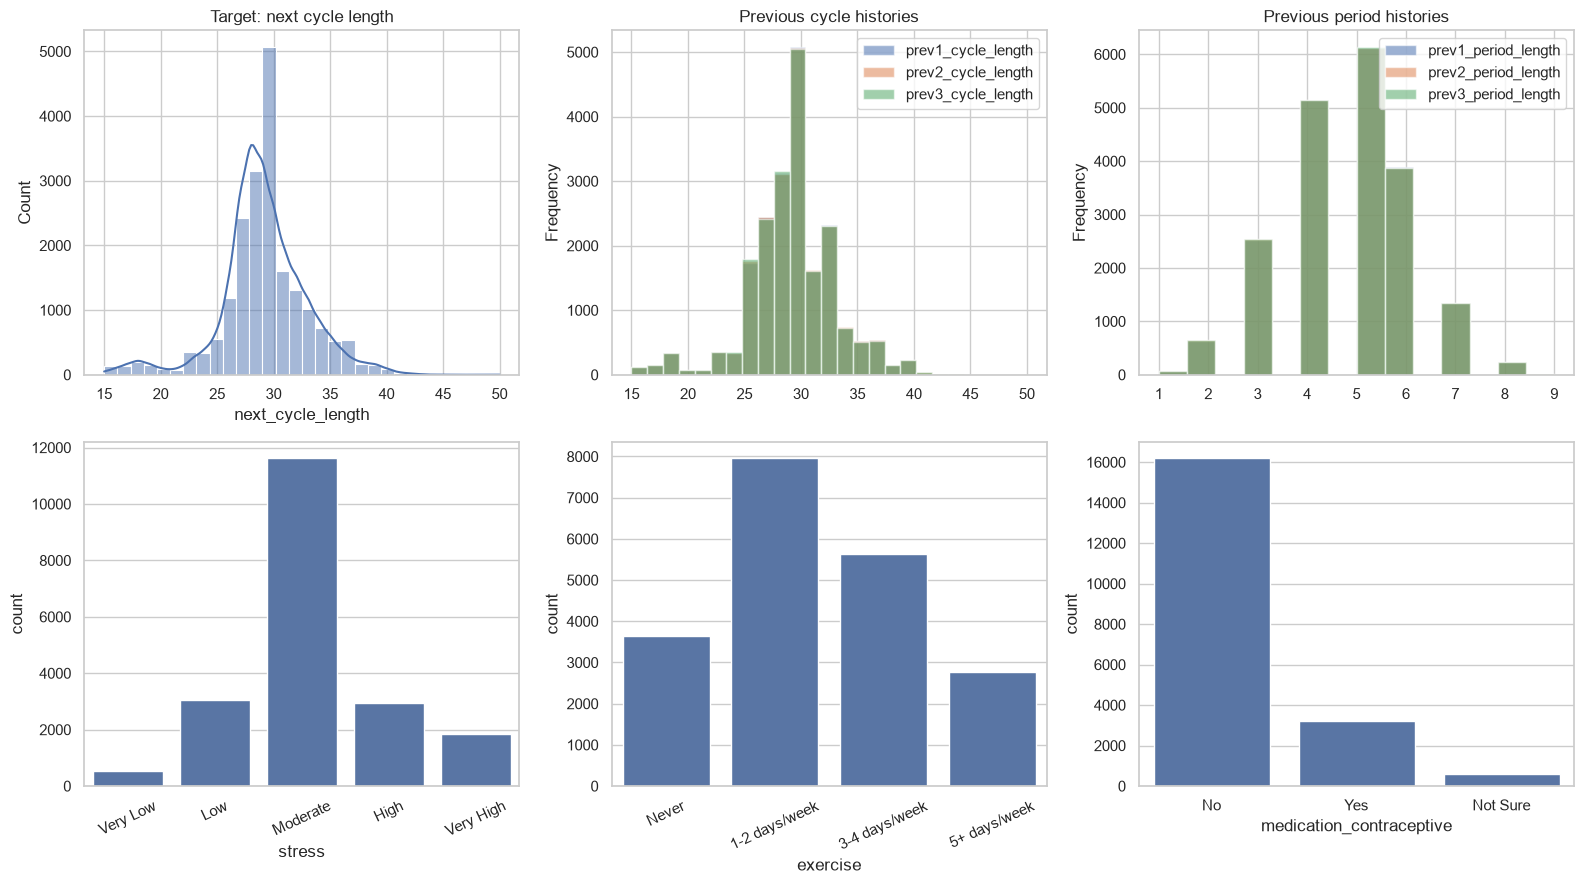

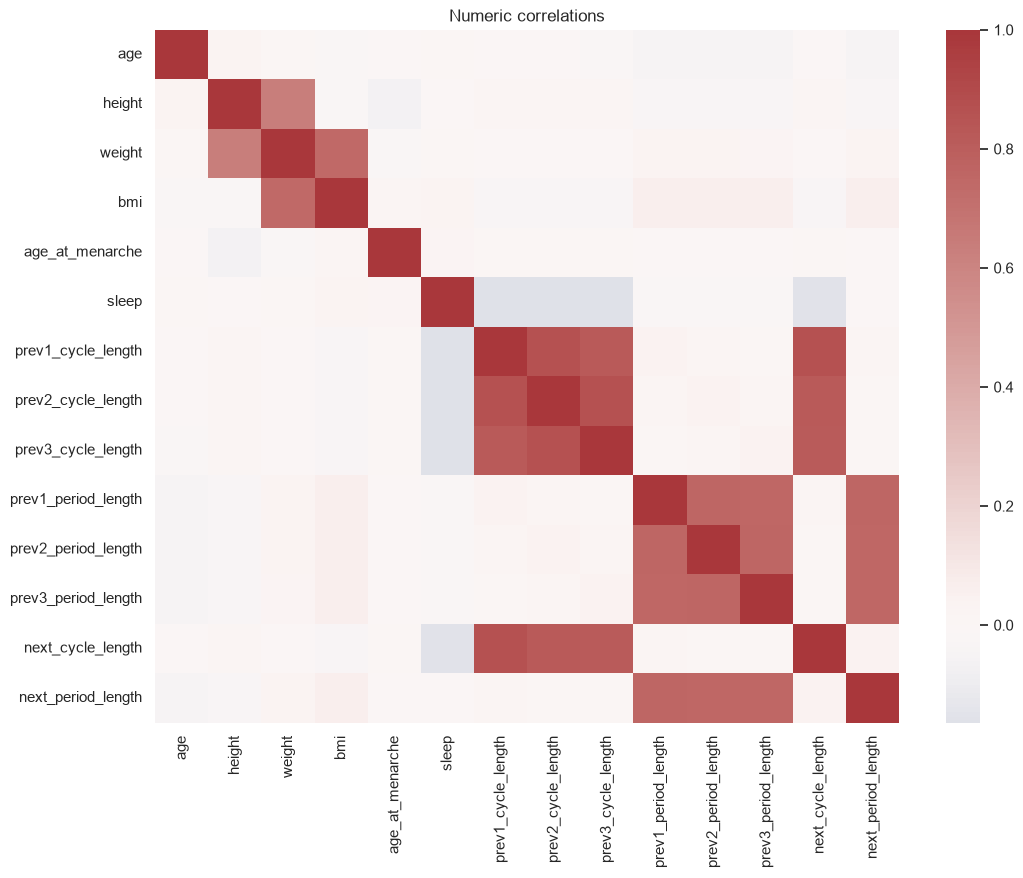

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sns.histplot(raw["next_cycle_length"], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Target: next cycle length")
raw[["prev1_cycle_length", "prev2_cycle_length", "prev3_cycle_length"]].plot(
    kind="hist", bins=25, alpha=0.55, ax=axes[0, 1]
)
axes[0, 1].set_title("Previous cycle histories")
raw[["prev1_period_length", "prev2_period_length", "prev3_period_length"]].plot(
    kind="hist", bins=14, alpha=0.55, ax=axes[0, 2]
)
axes[0, 2].set_title("Previous period histories")
sns.countplot(
    data=raw,
    x="stress",
    order=["Very Low", "Low", "Moderate", "High", "Very High"],
    ax=axes[1, 0],
)
axes[1, 0].tick_params(axis="x", rotation=25)
sns.countplot(data=raw, x="exercise", ax=axes[1, 1])
axes[1, 1].tick_params(axis="x", rotation=25)
sns.countplot(data=raw, x="medication_contraceptive", ax=axes[1, 2])
plt.tight_layout()
height_value = pd.to_numeric(raw["height"], errors="coerce")
height_cm_decimal_feet = height_value * 30.48
height_cm_feet_inches = (np.floor(height_value) * 12 + np.round((height_value - np.floor(height_value)) * 10)) * 2.54
weight_value = pd.to_numeric(raw["weight"], errors="coerce")
bmi_decimal_feet = weight_value / (height_cm_decimal_feet / 100) ** 2
bmi_feet_inches = weight_value / (height_cm_feet_inches / 100) ** 2
bmi_recalculated = bmi_feet_inches
display(
    pd.DataFrame(
        {
            "raw_bmi": raw["bmi"],
            "decimal_feet_bmi": bmi_decimal_feet,
            "feet_inches_bmi": bmi_feet_inches,
            "difference_from_feet_inches": raw["bmi"] - bmi_recalculated,
        }
    ).describe()
)
plt.figure(figsize=(12, 9))
sns.heatmap(raw.select_dtypes(include=np.number).corr(), cmap="vlag", center=0)
plt.title("Numeric correlations")
plt.show()

## 5. Longitudinal audit and reconstructed groups

The CSV has no explicit woman ID. The cell verifies the expected ordered 20-row blocks before reconstructing `woman_id` and `window_index`; these fields are audit/splitting fields only and never model features. Continuity compares every adjacent window within a woman.

In [6]:
id_candidates = [
    c
    for c in raw.columns
    if any(
        x in c.lower()
        for x in ["woman", "user", "patient", "subject", "participant", "id"]
    )
]
print("ID candidates:", id_candidates or "None")
assert len(raw) % 20 == 0, "Row count is not divisible by 20; do not reconstruct IDs."
audit = raw.copy()
audit["woman_id"] = np.arange(len(audit)) // 20 + 1
audit["window_index"] = np.arange(len(audit)) % 20 + 1


def continuity_pct(frame, pairs):
    previous = frame.groupby("woman_id")[list(pairs.values())].shift(1)
    valid = frame["window_index"].ne(1)
    checks = [(frame[now].eq(previous[old])) for now, old in pairs.items()]
    return pd.concat(checks, axis=1).all(axis=1)[valid].mean() * 100


cycle_pct = continuity_pct(
    audit,
    {
        "prev1_cycle_length": "next_cycle_length",
        "prev2_cycle_length": "prev1_cycle_length",
        "prev3_cycle_length": "prev2_cycle_length",
    },
)
period_pct = continuity_pct(
    audit,
    {
        "prev1_period_length": "next_period_length",
        "prev2_period_length": "prev1_period_length",
        "prev3_period_length": "prev2_period_length",
    },
)
irregular_pct = (
    continuity_pct(
        audit,
        {
            "prev1_irregular_flag": "next_is_irregular",
            "prev2_irregular_flag": "prev1_irregular_flag",
            "prev3_irregular_flag": "prev2_irregular_flag",
        },
    )
    if {
        "prev1_irregular_flag",
        "prev2_irregular_flag",
        "prev3_irregular_flag",
        "next_is_irregular",
    }.issubset(audit.columns)
    else np.nan
)
display(
    pd.DataFrame(
        {
            "series": ["cycle", "period", "irregularity"],
            "adjacent-window continuity pct": [cycle_pct, period_pct, irregular_pct],
        }
    )
)
assert (
    cycle_pct == 100
), "Cycle continuity failed; do not use reconstructed IDs without investigation."

ID candidates: None


,series,adjacent-window continuity pct
0,cycle,100.0
1,period,100.0
2,irregularity,100.0


## 6. Within/between-person variation and baseline

This cell tests the key product question: how well does the simple mean of the three previous cycles predict the next cycle? It also separates within-woman and between-woman variation.

,feature,women_with_change
0,age,0
1,height,0
2,weight,999
3,age_at_menarche,0
4,medication_contraceptive,0


Within-woman next-cycle SD summary:


count    1000.000000
mean        1.385919
std         0.894642
min         0.502625
25%         0.875094
50%         1.071153
75%         1.503505
max         7.114847
Name: next_cycle_length, dtype: float64

Between-woman mean-cycle SD: 3.5149205174148315


,MAE,MSE,RMSE,R2,correlation,within_1_day_pct,within_2_days_pct,exact_rounded_mean_pct
0,1.256,3.4597,1.86,0.7682,0.8793,61.415,85.12,29.86


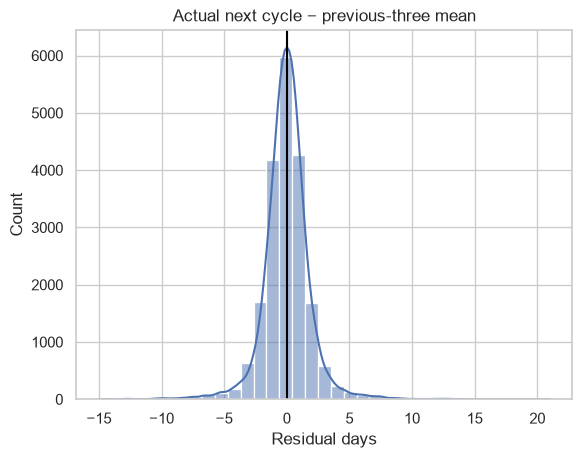

In [7]:
static_cols = ["age", "height", "weight", "age_at_menarche", "medication_contraceptive"]
display(
    pd.DataFrame(
        {
            "feature": static_cols,
            "women_with_change": [
                audit.groupby("woman_id")[c].nunique(dropna=False).gt(1).sum()
                for c in static_cols
            ],
        }
    )
)
within = audit.groupby("woman_id")["next_cycle_length"].std().describe()
between = audit.groupby("woman_id")["next_cycle_length"].mean().std()
print("Within-woman next-cycle SD summary:")
display(within)
print("Between-woman mean-cycle SD:", between)
baseline = audit[
    ["prev1_cycle_length", "prev2_cycle_length", "prev3_cycle_length"]
].mean(axis=1)
y = audit["next_cycle_length"]
metrics = {
    "MAE": mean_absolute_error(y, baseline),
    "MSE": mean_squared_error(y, baseline),
    "RMSE": mean_squared_error(y, baseline) ** 0.5,
    "R2": r2_score(y, baseline),
    "correlation": y.corr(baseline),
    "within_1_day_pct": (y.sub(baseline).abs() <= 1).mean() * 100,
    "within_2_days_pct": (y.sub(baseline).abs() <= 2).mean() * 100,
    "exact_rounded_mean_pct": (y.eq(baseline.round())).mean() * 100,
}
display(pd.DataFrame([metrics]).round(4))
residual = y - baseline
sns.histplot(residual, bins=35, kde=True)
plt.axvline(0, color="black")
plt.title("Actual next cycle − previous-three mean")
plt.xlabel("Residual days")
plt.show()

## Observation

Read the computed continuity and baseline results before modelling. High baseline performance is a real benchmark: a more complex model must improve validation and held-out test MAE, not merely look sophisticated. Current model performance reflects held-out simulated women and should be considered proof-of-concept validation rather than clinical validation on real users.